In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
import plotly.express as px
import nbformat
import plotly.graph_objects as go

In [4]:
fare = pd.read_csv("Avg_domestic_fare_USA.csv")

In [11]:
fare.head()

,Year,Nominal,Real
0,2024-01-01,402.72,402.72
1,2023-01-01,402.58,414.46
2,2022-01-01,404.84,433.94
3,2021-01-01,314.77,364.40
4,2020-01-01,305.09,369.78


In [10]:
fare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Year     7 non-null      datetime64[ns]
 1   Nominal  7 non-null      float64       
 2   Real     7 non-null      float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 300.0 bytes


In [9]:
fare['Year'] = pd.to_datetime(fare['Year'], format='%Y')

In [12]:
fare_real= fare['Real']
fare_nom = fare['Nominal']

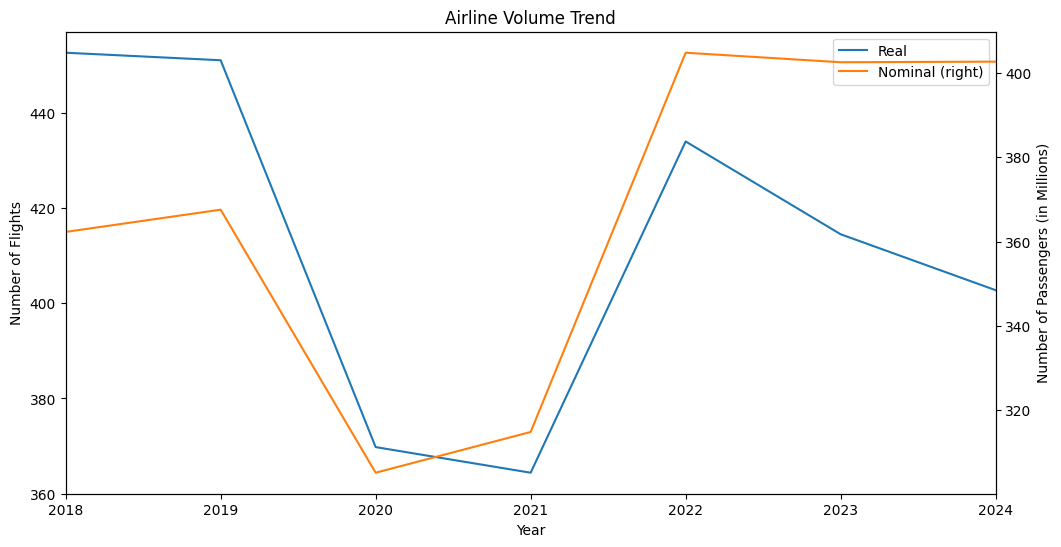

In [15]:
ax = fare.plot(x='Year', y='Real',  ylabel='Number of Flights', figsize=(12,6))
ax.set_title('Airline Volume Trend')

fare.plot(    
    x='Year',
    y='Nominal',
    ylabel='Number of Passengers (in Millions)',
    ax=ax,
    secondary_y=True
)

plt.show()

In [36]:
fig = go.Figure()

# First line (left y-axis)
fig.add_trace(go.Scatter(
    x=fare['Year'],
    y=fare['Real'],
    name='Real',
    mode='lines'
))

# Second line (right y-axis)
fig.add_trace(go.Scatter(
    x=fare['Year'],
    y=fare['Nominal'],
    name='Nominal',
    mode='lines',
    yaxis='y2'
))

# Layout (this replaces plt + labels + title)
fig.update_layout(    
    title='Real vs Nominal Average Round Trip Cost',
    xaxis=dict(title='Year'),
    yaxis=dict(title='Real Cost', tickprefix='$', tickfont=dict(color='blue'),),
    yaxis2=dict(
        title='Nominal Cost',
        tickprefix='$',
        tickfont=dict(color='red'),
        overlaying='y',
        side='right'
    ),
    
    width=800,
    height=500,
    template='plotly_white'
)

fig.show()